# Part 4 - True-talent xwOBA (empirical Bayes)

This is the part I actually wanted all along: a number for *analyzing a hitter*. For each batter-season I want an xwOBA that's been **regressed for sample size** — a scorching 120-PA line gets pulled back toward the league until the plate appearances justify it — paired with an interval that **narrows as PA grows**.

The method is deliberately simple: Gaussian–Gaussian empirical Bayes, no BART re-fit needed. Each estimate is

`theta_hat = mu + reliability * (raw - mu)`,  where  `reliability = tau^2 / (tau^2 + se^2)`.

In words: start at the league mean `mu`, and move toward the player's raw number only as far as the reliability of their sample allows. Everything here comes from `results/talent/`.

In [1]:
# --- setup: locate the repo and import the shared notebook helpers (run this first) ---
import sys
from pathlib import Path

_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists()), Path.cwd())
sys.path.insert(0, str(_root / "notebooks"))
from nb_helpers import ROOT, RESULTS, jload, show_fig

import polars as pl
from IPython.display import Markdown, display

print("repo root:", ROOT)
print("results:  ", RESULTS, "(exists)" if RESULTS.exists() else "(MISSING)")

repo root: C:\Users\H-100\Desktop\python\xwobart
results:   C:\Users\H-100\Desktop\python\xwobart\results (exists)


## Per-season hyperparameters

The two knobs — the league mean `mu` and the talent spread `tau` — are fit separately for each season, using only players with 100+ PA, then applied to everyone.

In [2]:
tm = jload("talent/talent_metrics.json")
pl.DataFrame([
    {"season": r["season"], "n": r["n"], "mu (league)": round(r["mu"], 4),
     "tau (spread)": round(r["tau"], 4), "median reliability": round(r["median_reliability"], 3)}
    for r in tm["per_season"]
])

season,n,mu (league),tau (spread),median reliability
2022,678,0.3046,0.0312,0.645
2023,647,0.3142,0.0308,0.643
2024,645,0.3103,0.0307,0.654
2025,666,0.3179,0.0323,0.648


## Shrinkage in action

Here's the whole idea in one picture: small samples collapse toward the season mean, while big samples barely budge.

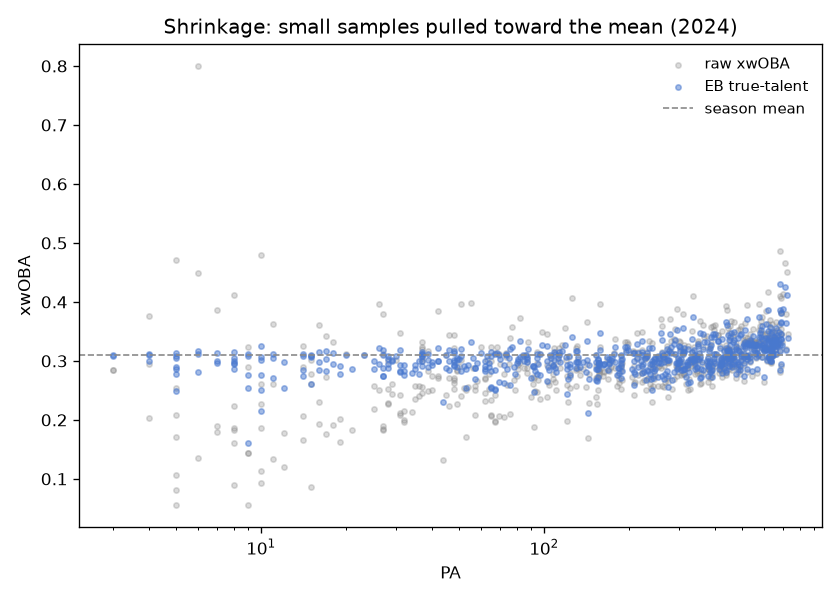

*2024 player-seasons on a log-PA axis: raw xwOBA (grey) scatters wildly at low PA; the talent estimate (blue) hugs the dashed season mean until the sample earns a gap.*

In [3]:
show_fig("talent/figures/shrinkage_raw_to_talent.png",
         caption="2024 player-seasons on a log-PA axis: raw xwOBA (grey) scatters wildly at low PA; the talent estimate (blue) hugs the dashed season mean until the sample earns a gap.")

The dial doing that work is **reliability** — the share of the raw number the estimator keeps. What to look for below: it climbs steeply through the first 100 PA (about 0.5 there) and levels off near 0.8 for everyday players. And note the stray points pinned at 1.0 on the far left — tiny samples whose outcomes happened not to vary, so the estimator thinks they're perfectly measured. That pathology is the bug Part 5 catches and fixes.

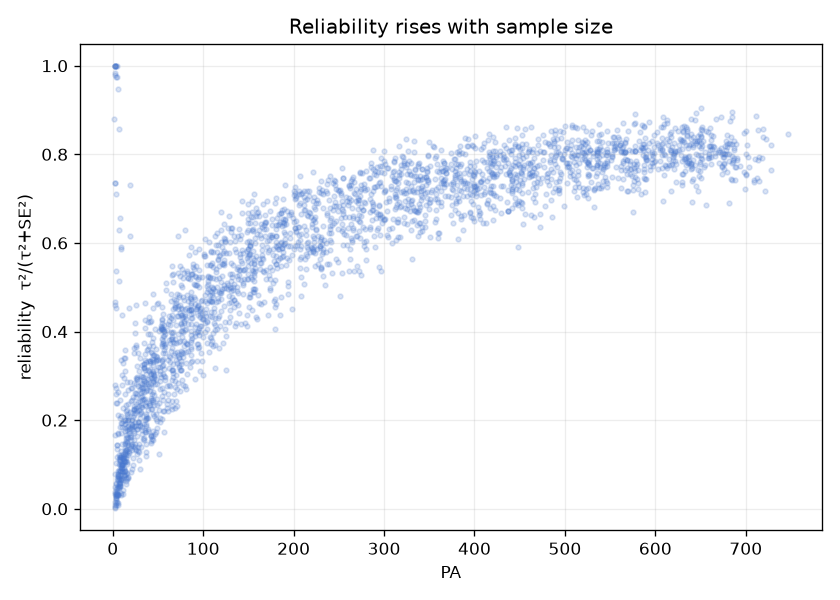

*Reliability τ²/(τ²+SE²) vs PA — ~0.5 near 100 PA, ~0.8 by 500. The 1.0s at far left are zero-variance small samples, fixed in Part 5.*

In [4]:
show_fig("talent/figures/reliability_vs_pa.png",
         caption="Reliability τ²/(τ²+SE²) vs PA — ~0.5 near 100 PA, ~0.8 by 500. The 1.0s at far left are zero-variance small samples, fixed in Part 5.")

## A few concrete examples — raw → talent

Abstractions are easier to trust with names attached, so here are a handful of players run through the estimator.

In [5]:
t = pl.read_parquet(RESULTS / "talent" / "talent_table.parquet")
def ex(name, season):
    r = t.filter((pl.col("player_name") == name) & (pl.col("season") == season)).row(0, named=True)
    return {"player": name, "season": season, "PA": r["PA"],
            "raw": round(r["xwoba_raw"], 3), "talent": round(r["xwoba_talent"], 3),
            "90% lo": round(r["talent_lo"], 3), "90% hi": round(r["talent_hi"], 3),
            "reliability": round(r["reliability"], 3)}
pl.DataFrame([
    ex("Khalil Lee", 2022),     # 2 PA, extreme hot -> fully regressed to league
    ex("Mike Trout", 2024),     # 125 PA, hot -> pulled down to a believable .341
    ex("Austin Hedges", 2024),  # 143 PA, cold, low-variance -> pulled up
])

player,season,PA,raw,talent,90% lo,90% hi,reliability
"""Khalil Lee""",2022,2,0.911,0.305,0.254,0.357,0.001
"""Mike Trout""",2024,125,0.407,0.341,0.299,0.383,0.313
"""Austin Hedges""",2024,143,0.168,0.212,0.184,0.24,0.695


Worth pausing on Trout here: he gets regressed *harder* than Hedges at a similar PA count. That's not a bug — it's the estimator leaning on each player's own noisiness (Trout's boom-or-bust, high per-PA variance) rather than just counting plate appearances.

## The payoff — does shrinkage actually predict better?

Fancy method, fine. But does regressing for sample size predict next season any better than the raw number, or than Savant?

In [6]:
v = tm["validation"]
def row(label, block):
    return {"population": label, "n": block["n"],
            "EB talent r": round(block["xwoba_talent"]["r"], 4),
            "raw r": round(block["xwoba_raw"]["r"], 4),
            "Savant r": round(block["xwoba_savant"]["r"], 4)}
pl.DataFrame([
    row("pooled, PA_T >= 100 (vs 0.487 anchor)", v["pooled_pa_min"]),
    row("pooled, PA_T >= 30 (admits low-PA)", v["pooled_lowpa_inclusive"]),
])

population,n,EB talent r,raw r,Savant r
"""pooled, PA_T >= 100 (vs 0.487 …",1060,0.4886,0.4835,0.4908
"""pooled, PA_T >= 30 (admits low…",1173,0.4669,0.4454,0.4521


The verdict: EB talent beats the raw number in both populations, and it **beats Savant once genuinely low-PA seasons are allowed in** (0.467 vs 0.452). At the 100+ PA anchor it ties Savant (0.489 vs 0.491) — the same parity I hit in Part 2, except now the *center* of the estimate is sample-size-honest.

### Why the win shows up pooled, not per-band (and why that isn't a bug)

In [7]:
bands = pl.DataFrame([
    {"PA band": b["band"], "n": b["n"], "median reliability": round(b["median_reliability"], 2),
     "|talent-raw|": round(b["mean_abs_talent_minus_raw"], 4),
     "talent r": round(b["xwoba_talent"]["r"], 3), "raw r": round(b["xwoba_raw"]["r"], 3),
     "savant r": round(b["xwoba_savant"]["r"], 3)}
    for b in v["by_band"]
])
bands

PA band,n,median reliability,|talent-raw|,talent r,raw r,savant r
"""[30,60)""",50,0.27,0.0409,0.239,0.209,0.211
"""[60,100)""",63,0.39,0.0186,0.088,0.11,0.128
"""[100,250)""",227,0.57,0.013,0.277,0.278,0.293
"""[250,inf)""",833,0.77,0.0069,0.512,0.516,0.523


Here's the subtle part. Inside a narrow PA band, reliability is nearly constant, so `theta_hat = mu(1 - c) + c * raw` is essentially *affine* in the raw number — and Pearson r doesn't care about affine transforms. So per-band r *can't* move much no matter how good the shrinkage is; those tiny per-band gaps are just noise.

Where shrinkage actually pays off is across a *heterogeneous*-PA population: it compresses the wild low-PA raw numbers, and that only shows up in the pooled r. So this is a property of the estimator, not a bug — I wrote it up in `results/talent/NOTES.md`.

## The biggest shrinks

For fun, here are the ten hitters the estimator moved the most — the hot and cold small samples that got yanked back toward the mean.

In [8]:
pl.DataFrame([
    {"player": r["player_name"], "season": r["season"], "PA": r["PA"],
     "raw": round(r["xwoba_raw"], 3), "talent": round(r["xwoba_talent"], 3),
     "reliability": round(r["reliability"], 3)}
    for r in tm["biggest_shrinks"][:10]
])

player,season,PA,raw,talent,reliability
"""Khalil Lee""",2022,2,0.911,0.305,0.001
"""Stone Garrett""",2024,6,0.801,0.317,0.013
"""Tristan Gray""",2023,4,0.705,0.317,0.008
"""Zack Collins""",2023,6,0.529,0.321,0.031
"""Grant Koch""",2024,8,0.09,0.286,0.11
"""Jeter Downs""",2023,9,0.531,0.335,0.097
"""Tyler Gentry""",2024,5,0.082,0.277,0.145
"""Aramis Garcia""",2025,4,0.054,0.249,0.26
"""Brewer Hicklen""",2024,5,0.055,0.25,0.238
"""Chadwick Tromp""",2022,4,0.503,0.309,0.024


## What's next — Phase 2

There's an obvious weakness in all of this: right now every player is shrunk toward the *league* mean. But a rookie who's barreling everything shouldn't regress toward average — he should regress toward a slugger.

My first instinct was to shrink toward the BART model's own xwOBA prediction, and that turned out to be a dead end — a structural no-op. The BART surface is built from the *same batted balls* as the raw number, so once you take it apart there's essentially no residual spread left to shrink toward (τ_resid² ≈ 1e-4). Nothing to gain.

What actually works is putting the **peripherals** — average exit velocity and barrel rate — into the prior. They stabilize much faster than xwOBA does, so at 40 PA they know things the xwOBA sample doesn't yet. That's Part 5.

In [9]:
# guard: the numbers quoted in the prose above vs the artifacts — fails loudly on drift.
_lo, _hi = v["pooled_lowpa_inclusive"], v["pooled_pa_min"]
assert round(_lo["xwoba_talent"]["r"], 3) == 0.467 and round(_lo["xwoba_savant"]["r"], 3) == 0.452  # "beats Savant at low PA (0.467 vs 0.452)"
assert round(_hi["xwoba_talent"]["r"], 3) == 0.489 and round(_hi["xwoba_savant"]["r"], 3) == 0.491  # "ties Savant (0.489 vs 0.491)"
_taus = sorted(round(r["tau"], 4) for r in tm["per_season"])
assert _taus[0] == 0.0307 and _taus[-1] == 0.0323      # the tau range Part 5 quotes back
print("prose numbers still match the artifacts")

prose numbers still match the artifacts
